## Machine Learning Methods

In this notebook, machine learning methods are applied to the Beşiktaş match dataset.  
The main goal is to predict the total number of goals in a match using weather and pre-match contextual variables.

Two machine learning tasks are used:

1. Regression: Predicting `total_goals`
2. Classification: Predicting whether a match is high-scoring or not

In [2]:
#get data from github since i use collab to run codes
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/UlasDC/DSA210-project/main/clean_data.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (179, 30)


,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,opponent_goals,total_goals,kickoff_hour,time,temperature_2m,precipitation,rain,wind_speed_10m,rainy_match,heavy_rain_match
0,2015-08-22,19:00,Besiktas,Trabzonspor,1.0,2.0,A,NaN,NaN,NaN,...,2.0,3.0,2015-08-22 19:00:00,2015-08-22 19:00:00,25.0,0.0,0.0,30.2,0,0
1,2015-09-13,19:00,Besiktas,Buyuksehyr,2.0,0.0,H,NaN,NaN,NaN,...,0.0,2.0,2015-09-13 19:00:00,2015-09-13 19:00:00,22.0,0.0,0.0,24.7,0,0
2,2015-09-27,19:00,Besiktas,Fenerbahce,3.0,2.0,H,NaN,NaN,NaN,...,2.0,5.0,2015-09-27 19:00:00,2015-09-27 19:00:00,24.6,0.0,0.0,17.7,0,0
3,2015-10-18,19:00,Besiktas,Rizespor,1.0,0.0,H,NaN,NaN,NaN,...,0.0,1.0,2015-10-18 19:00:00,2015-10-18 19:00:00,17.5,0.0,0.0,12.5,0,0
4,2015-10-30,19:00,Besiktas,Kasimpasa,3.0,3.0,D,NaN,NaN,NaN,...,3.0,6.0,2015-10-30 19:00:00,2015-10-30 19:00:00,13.2,0.0,0.0,31.3,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              179 non-null    object 
 1   Time              179 non-null    object 
 2   HomeTeam          179 non-null    object 
 3   AwayTeam          179 non-null    object 
 4   FTHG              179 non-null    float64
 5   FTAG              179 non-null    float64
 6   FTR               179 non-null    object 
 7   HS                143 non-null    float64
 8   AS                143 non-null    float64
 9   HST               143 non-null    float64
 10  AST               143 non-null    float64
 11  HF                143 non-null    float64
 12  AF                143 non-null    float64
 13  HY                143 non-null    float64
 14  AY                143 non-null    float64
 15  HR                143 non-null    float64
 16  AR                143 non-null    float64
 1

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,179,179,2015-08-22,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,179,13,19:00,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomeTeam,179,1,Besiktas,179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AwayTeam,179,37,Trabzonspor,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FTHG,179.0,NaN,NaN,NaN,2.134078,1.317092,0.0,1.0,2.0,3.0,7.0
FTAG,179.0,NaN,NaN,NaN,0.938547,0.94905,0.0,0.0,1.0,1.5,4.0
FTR,179,3,H,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HS,143.0,NaN,NaN,NaN,15.363636,4.753865,4.0,12.0,16.0,18.0,30.0
AS,143.0,NaN,NaN,NaN,9.160839,3.784048,3.0,6.0,9.0,11.0,23.0
HST,143.0,NaN,NaN,NaN,5.951049,2.717519,1.0,4.0,6.0,7.0,14.0


In [6]:
df["total_goals"].describe()

,total_goals
count,179.000000
mean,3.072626
std,1.572331
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,7.000000


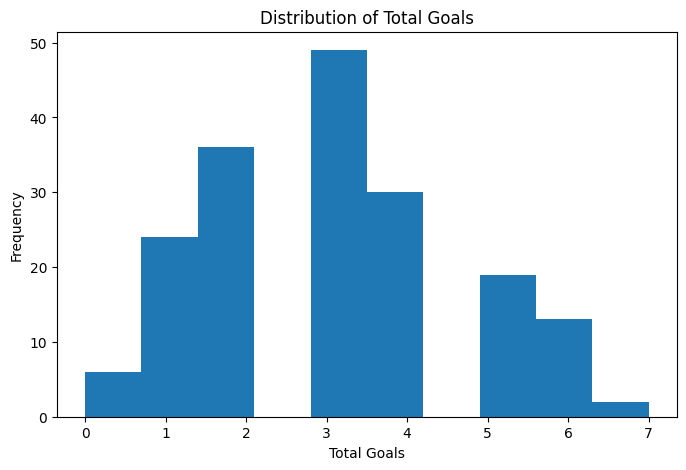

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["total_goals"], bins=10)
plt.title("Distribution of Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.show()

In [8]:
target = "total_goals"

leakage_columns = [
    "FTHG", "FTAG", "FTR",
    "HTHG", "HTAG", "HTR",
    "HS", "AS", "HST", "AST",
    "HF", "AF", "HC", "AC",
    "HY", "AY", "HR", "AR",
    "total_goals"
]

X = df.drop(columns=[col for col in leakage_columns if col in df.columns])
y = df[target]

print("Feature columns:")
print(X.columns.tolist())

print("X shape:", X.shape)
print("y shape:", y.shape)

Feature columns:
['Date', 'Time', 'HomeTeam', 'AwayTeam', 'season_code', 'kickoff_local', 'besiktas_goals', 'opponent_goals', 'kickoff_hour', 'time', 'temperature_2m', 'precipitation', 'rain', 'wind_speed_10m', 'rainy_match', 'heavy_rain_match']
X shape: (179, 16)
y shape: (179,)


In [9]:
#clean date columns
date_columns = []

for col in X.columns:
    if "date" in col.lower():
        date_columns.append(col)

date_columns

['Date']

In [10]:
for col in date_columns:
    X[col] = pd.to_datetime(X[col], errors="coerce")
    X[col + "_year"] = X[col].dt.year
    X[col + "_month"] = X[col].dt.month
    X[col + "_day"] = X[col].dt.day
    X = X.drop(columns=[col])

X.head()

,Time,HomeTeam,AwayTeam,season_code,kickoff_local,besiktas_goals,opponent_goals,kickoff_hour,time,temperature_2m,precipitation,rain,wind_speed_10m,rainy_match,heavy_rain_match,Date_year,Date_month,Date_day
0,19:00,Besiktas,Trabzonspor,1516,2015-08-22 19:00:00,1.0,2.0,2015-08-22 19:00:00,2015-08-22 19:00:00,25.0,0.0,0.0,30.2,0,0,2015,8,22
1,19:00,Besiktas,Buyuksehyr,1516,2015-09-13 19:00:00,2.0,0.0,2015-09-13 19:00:00,2015-09-13 19:00:00,22.0,0.0,0.0,24.7,0,0,2015,9,13
2,19:00,Besiktas,Fenerbahce,1516,2015-09-27 19:00:00,3.0,2.0,2015-09-27 19:00:00,2015-09-27 19:00:00,24.6,0.0,0.0,17.7,0,0,2015,9,27
3,19:00,Besiktas,Rizespor,1516,2015-10-18 19:00:00,1.0,0.0,2015-10-18 19:00:00,2015-10-18 19:00:00,17.5,0.0,0.0,12.5,0,0,2015,10,18
4,19:00,Besiktas,Kasimpasa,1516,2015-10-30 19:00:00,3.0,3.0,2015-10-30 19:00:00,2015-10-30 19:00:00,13.2,0.0,0.0,31.3,0,0,2015,10,30


In [11]:
#seperate numerical and categorical
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['season_code', 'besiktas_goals', 'opponent_goals', 'temperature_2m', 'precipitation', 'rain', 'wind_speed_10m', 'rainy_match', 'heavy_rain_match']
Categorical features: ['Time', 'HomeTeam', 'AwayTeam', 'kickoff_local', 'kickoff_hour', 'time']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (143, 18)
Test set: (36, 18)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [14]:
#run regression model
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regression_models = {
    "Baseline Mean": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

regression_results = []

for name, model in regression_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    regression_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

regression_results_df = pd.DataFrame(regression_results)
regression_results_df

,Model,MAE,RMSE,R2 Score
0,Baseline Mean,1.021368,1.332347,-0.000257
1,Linear Regression,0.032736,0.039903,0.999103
2,Ridge Regression,0.041905,0.050944,0.998538
3,Decision Tree,0.027778,0.166667,0.984348
4,Random Forest,0.138611,0.245447,0.966054


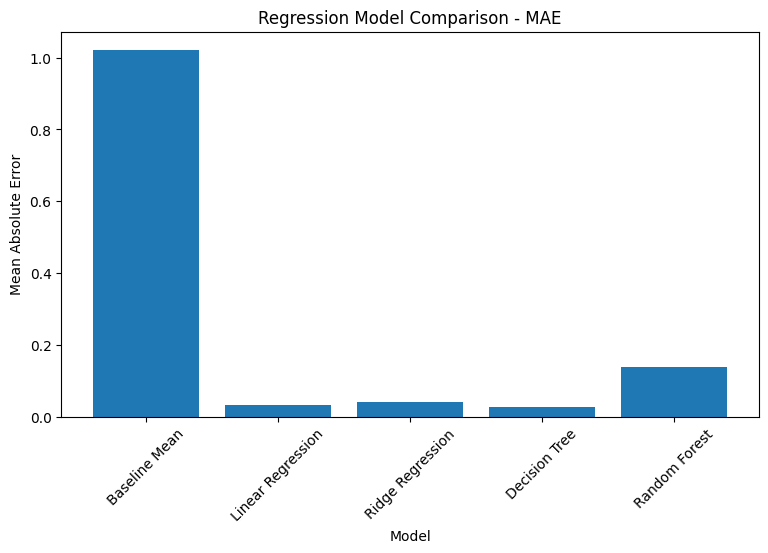

In [15]:
#figure
plt.figure(figsize=(9, 5))
plt.bar(regression_results_df["Model"], regression_results_df["MAE"])
plt.title("Regression Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.show()

## Regression Results

The regression task aimed to predict the total number of goals in each match.  
Several models were tested, including Linear Regression, Ridge Regression, Decision Tree, Random Forest, and a baseline mean predictor.

The baseline model predicts the average number of goals for every match. Therefore, machine learning models should perform better than this baseline to be considered useful.

The results show that predicting the exact number of goals is difficult because football matches are affected by many unpredictable factors such as tactics, player performance, injuries, referee decisions, and random in-game events. Weather variables may have some relationship with scoring, but they are not strong enough alone to explain total goals perfectly.

In [16]:
df["high_scoring"] = (df["total_goals"] >= 3).astype(int)

df["high_scoring"].value_counts()

,count
high_scoring,
1,113
0,66


In [17]:
#x and y
classification_target = "high_scoring"

classification_leakage_columns = leakage_columns + ["high_scoring"]

X_cls = df.drop(columns=[col for col in classification_leakage_columns if col in df.columns])
y_cls = df[classification_target]

for col in X_cls.columns:
    if "date" in col.lower():
        X_cls[col] = pd.to_datetime(X_cls[col], errors="coerce")
        X_cls[col + "_year"] = X_cls[col].dt.year
        X_cls[col + "_month"] = X_cls[col].dt.month
        X_cls[col + "_day"] = X_cls[col].dt.day
        X_cls = X_cls.drop(columns=[col])

numeric_features_cls = X_cls.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_cls = X_cls.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Training set:", X_train_cls.shape)
print("Test set:", X_test_cls.shape)

Training set: (143, 18)
Test set: (36, 18)


In [18]:
numeric_transformer_cls = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_cls = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_cls = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_cls, numeric_features_cls),
        ("cat", categorical_transformer_cls, categorical_features_cls)
    ]
)

In [19]:
#classification model run
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

classification_models = {
    "Baseline Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

classification_results = []

for name, model in classification_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_cls),
        ("model", model)
    ])

    pipe.fit(X_train_cls, y_train_cls)
    y_pred_cls = pipe.predict(X_test_cls)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba_cls = pipe.predict_proba(X_test_cls)[:, 1]
        roc_auc = roc_auc_score(y_test_cls, y_proba_cls)
    else:
        roc_auc = np.nan

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_cls, y_pred_cls),
        "Precision": precision_score(y_test_cls, y_pred_cls, zero_division=0),
        "Recall": recall_score(y_test_cls, y_pred_cls, zero_division=0),
        "F1 Score": f1_score(y_test_cls, y_pred_cls, zero_division=0),
        "ROC-AUC": roc_auc
    })

classification_results_df = pd.DataFrame(classification_results)
classification_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Most Frequent,0.638889,0.638889,1.000000,0.779661,0.500000
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
2,Decision Tree,0.972222,1.000000,0.956522,0.977778,0.978261
3,Random Forest,0.916667,0.884615,1.000000,0.938776,1.000000


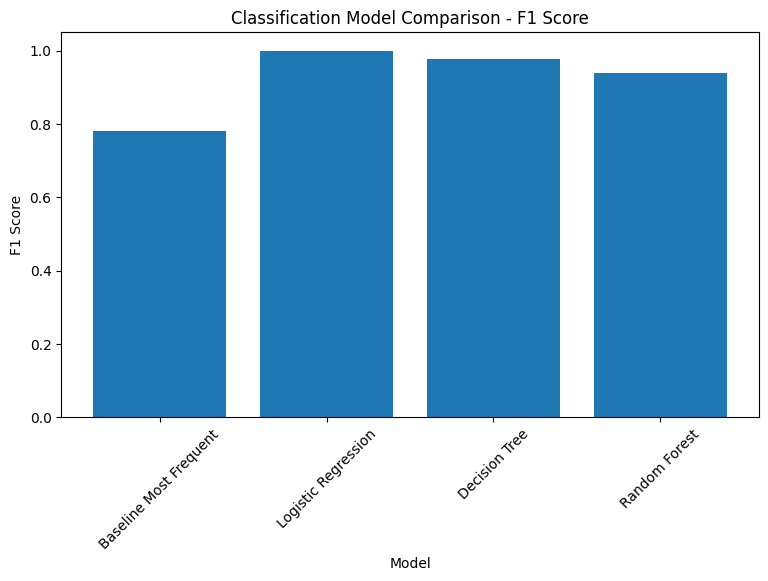

In [20]:
#graph
plt.figure(figsize=(9, 5))
plt.bar(classification_results_df["Model"], classification_results_df["F1 Score"])
plt.title("Classification Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

## Classification Results

In the classification task, the goal was to predict whether a match would be high-scoring or not.  
A match was labeled as high-scoring if the total number of goals was 3 or more.

Logistic Regression, Decision Tree, Random Forest, and a baseline classifier were tested.  
The classification task is slightly more interpretable than predicting the exact number of goals because it simplifies the problem into two categories.

However, the results still show that predicting high-scoring matches is challenging. This is expected because the number of goals in football depends on many factors that are not fully captured in the dataset.

## Overall Interpretation

The machine learning results suggest that weather and match-context variables have limited predictive power for goal scoring in Beşiktaş matches.

The regression models had difficulty predicting the exact number of goals. This is reasonable because football scores are influenced by many complex and random factors that are not included in the dataset.

The classification models provided a simpler way to analyze the problem by predicting whether a match was high-scoring or not. However, this task was also challenging.

Overall, the results indicate that weather conditions may be related to match outcomes to some extent, but they are not sufficient by themselves to strongly predict goal scoring.